In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

values=np.random.rand(100)
# print(values)

labels=[]
for i in values[:50]:
    if i<0.5:
        labels.append('class1')
    else:
        labels.append('class2')
labels+=[None]*50
print(labels)
# labels=labels[:100]
# print(labels)

['class1', 'class2', 'class2', 'class2', 'class1', 'class1', 'class1', 'class2', 'class2', 'class2', 'class1', 'class2', 'class2', 'class1', 'class1', 'class1', 'class1', 'class2', 'class1', 'class1', 'class2', 'class1', 'class1', 'class1', 'class1', 'class2', 'class1', 'class2', 'class2', 'class1', 'class2', 'class1', 'class1', 'class2', 'class2', 'class2', 'class1', 'class1', 'class2', 'class1', 'class1', 'class1', 'class1', 'class2', 'class1', 'class2', 'class1', 'class2', 'class2', 'class1', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [2]:
len(values)
len(labels)

100

In [3]:
data={
    "point":[f'x{i+1}' for i in range(100)],
    "value":values,
    "label":labels
}
df=pd.DataFrame(data)
df.head()

,point,value,label
0,x1,0.374540,class1
1,x2,0.950714,class2
2,x3,0.731994,class2
3,x4,0.598658,class2
4,x5,0.156019,class1


In [4]:
varible_meaning={
    "point":"The point number",
    "value":"The value of the point",
    "label":"The class of the point"
}
varible_df=pd.DataFrame(list(varible_meaning.items()),columns=["Variable","Meaning"])
varible_df

,Variable,Meaning
0,point,The point number
1,value,The value of the point
2,label,The class of the point


In [5]:
df.nunique()

point    100
value    100
label      2
dtype: int64

In [6]:
df.shape
# df.info()
# df.describe().T
# df.isnull().sum()
# df.head()

(100, 3)

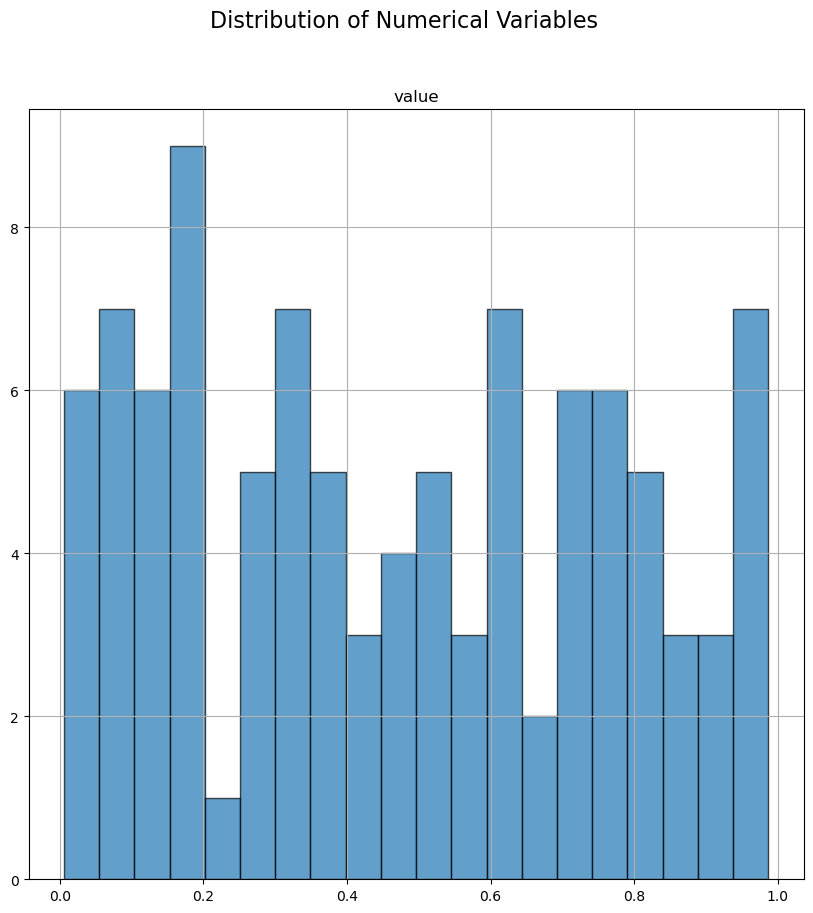

In [7]:
num_col=df.select_dtypes(include=['int64','float64']).columns
df[num_col].hist(figsize=(10,10),bins=20,edgecolor='black',alpha=0.7)
plt.suptitle('Distribution of Numerical Variables',fontsize=16)
plt.show()

In [63]:
# Split labeled data
labeled_df = df[df["label"].notna()]

X_train = labeled_df[["value"]]
y_train = labeled_df["label"]

# Split unlabeled data
unlabeled_df = df[df["label"].isna()]
X_test = unlabeled_df[["value"]]

# True labels (for checking accuracy)
true_labels = ["class1" if x <= 0.5 else "class2" for x in values[50:]]

# K values
k_values = [1,2,3,4,5,20,30]

# Store results
result = {}
accuracies = {}
for jk in k_values:
    knn=KNeighborsClassifier(n_neighbors=jk)
    knn.fit(X_train,y_train)
    pred=knn.predict(X_test)
    result[jk]=pred
    accuracies[jk]=accuracy_score(true_labels,pred)
    # print(f"K={jk},Accuracy={accuracies[jk]}")
    unlabeled_df[f"label_k{jk}"]=pred
    # print(unlabeled_df)
df1 = unlabeled_df.drop(columns=['label'], axis=1) 
df1
for k,acc in accuracies.items():
    print(f"K={k},Accuracy={acc}")

K=1,Accuracy=1.0
K=2,Accuracy=1.0
K=3,Accuracy=0.98
K=4,Accuracy=0.98
K=5,Accuracy=0.98
K=20,Accuracy=0.98
K=30,Accuracy=1.0


In [64]:
len(unlabeled_df) == 0 
print(len(labeled_df))
print(len(unlabeled_df))

50
50


In [65]:
result

{1: array(['class2', 'class2', 'class2', 'class2', 'class2', 'class2',
        'class1', 'class1', 'class1', 'class1', 'class1', 'class1',
        'class2', 'class1', 'class1', 'class2', 'class1', 'class2',
        'class1', 'class2', 'class2', 'class1', 'class1', 'class2',
        'class2', 'class2', 'class2', 'class1', 'class1', 'class1',
        'class2', 'class2', 'class1', 'class1', 'class1', 'class1',
        'class2', 'class2', 'class2', 'class1', 'class1', 'class2',
        'class2', 'class2', 'class2', 'class1', 'class2', 'class1',
        'class1', 'class1'], dtype=object),
 2: array(['class2', 'class2', 'class2', 'class2', 'class2', 'class2',
        'class1', 'class1', 'class1', 'class1', 'class1', 'class1',
        'class2', 'class1', 'class1', 'class2', 'class1', 'class2',
        'class1', 'class2', 'class2', 'class1', 'class1', 'class2',
        'class2', 'class2', 'class2', 'class1', 'class1', 'class1',
        'class2', 'class2', 'class1', 'class1', 'class1', 'class1'